In [18]:
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [19]:
df = pd.read_csv(r"C:\Users\usuario1\Documents\Churn.csv")
print(df.info())
print(df.describe())
print(df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age       Tenure  \
count  10000

In [20]:
print(df["Exited"].value_counts())
print(df["Exited"].value_counts(normalize = True))

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


aqui investigue el desequilibrio de clases en la columna objetivo Exited , logrando ver que hay una gran diferencia entre las dos clases ya que la cantidad de personas que no se han ido todavia (0) son el 0.7963 del total de la columna, mientras los clientes que ya se fueron (1) son unicamente el 0.2037 de la columna objetivo

In [21]:
print('Valores faltantes en Tenure :', df['Tenure'].isnull().sum())
df['Tenure'].fillna(df['Tenure'].median(), inplace = True)


Valores faltantes en Tenure : 909


C:\Users\usuario1\AppData\Local\Temp\ipykernel_34124\295036592.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Tenure'].fillna(df['Tenure'].median(), inplace = True)


In [22]:
df = df.drop(['RowNumber','CustomerId', 'Surname'], axis = 1)
df = pd.get_dummies(df, columns = ['Geography', 'Gender'], drop_first = True )

In [23]:
features = df.drop(['Exited'], axis = 1)
objetivo = df['Exited']
features_train, features_temp, objetivo_train , objetivo_temp = train_test_split (features, objetivo, test_size = 0.4, random_state = 12345)
features_valid, features_test, objetivo_valid, objetivo_test = train_test_split (features_temp, objetivo_temp, test_size = 0.5, random_state = 12345)

In [24]:
for n_est in [50, 100, 200]:
    model = RandomForestClassifier(random_state = 12345, n_estimators = n_est)
    model.fit(features_train, objetivo_train)
    prediccion = model.predict (features_valid)
    f1 = f1_score(objetivo_valid, prediccion)
    print (f"n_estimators ={n_est}: F1_score = {f1}")

n_estimators =50: F1_score = 0.5697151424287856
n_estimators =100: F1_score = 0.5748502994011976
n_estimators =200: F1_score = 0.5877061469265368


aqui como podemos observar el modelo con 200 n estimators fue el mas cercano a conseguir el f1 esperado, sin embargo,  no se cumplio con el f1 esperado, logrando unicamente 0.587, por lo tanto se entrenara otro modelo para llegar al resultado esperado 

In [25]:
model_log = LogisticRegression (random_state = 12345)
model_log.fit(features_train , objetivo_train)
prediccion_2 = model_log.predict(features_valid)
f1_log = f1_score (objetivo_valid, prediccion_2)
print(f"F1_score regression logistica = {f1_log}")

F1_score regression logistica = 0.10224948875255624


c:\Users\usuario1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


 aqui podemos determinar que el modelo de regresion logistica no cumplio con el f1 establecido ya que su f1 fue de .08

Al terminar de entrenar los modelos con los datos ,ninguno de los dos modelos logro el f1 que buscabamos, el modelo 1 dio un 0.587 cuando lo que se pide es un 0.59 siendo el mas cercano de los dos al f1 antes planteado, mientras el modelo de regresion lineal tuvo unicamente un F1 de .08, por lo mismo se hara una mejora de los modelos 

In [26]:
model_1_mejorado = RandomForestClassifier(random_state = 12345, n_estimators = 100 , class_weight = 'balanced')
model_1_mejorado.fit(features_train, objetivo_train)
pred_prob = model_1_mejorado.predict_proba(features_valid)[:,1]
for threshold in [0.3, 0.35 , 0.4, 0.45, 0.5]:
    pred_threshold = (pred_prob >= threshold)
    f1_new = f1_score(objetivo_valid , pred_threshold)
    print(f"Threshold {threshold} : F1 = {f1_new}")
    
    

Threshold 0.3 : F1 = 0.6050228310502284
Threshold 0.35 : F1 = 0.6170731707317073
Threshold 0.4 : F1 = 0.5871313672922251
Threshold 0.45 : F1 = 0.5867418899858956
Threshold 0.5 : F1 = 0.5722983257229832


Con el modelo de RandomForestClassifier mejorado se logro superar al F1 que se establecio el cual era de 0.59 , logrando un F1 de 0.617 con un umbral de 0.35

In [27]:
model_log_mej = LogisticRegression(random_state = 12345, class_weight ='balanced')
model_log_mej.fit(features_train , objetivo_train)
log_pred_prob= model_log_mej.predict_proba(features_valid)[:,1]
for threshold in [0.3, 0.35, 0.4, 0.45 , 0.5] :
    pred_log_thre = (log_pred_prob  >= threshold)
    f1_log_new = f1_score(objetivo_valid , pred_log_thre)
    print(f'threshold {threshold} : F1 = {f1_log_new}')
    


threshold 0.3 : F1 = 0.38090692124105013
threshold 0.35 : F1 = 0.4023048716605553
threshold 0.4 : F1 = 0.4288266825491364
threshold 0.45 : F1 = 0.4423465947403911
threshold 0.5 : F1 = 0.4581704456606724


c:\Users\usuario1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Como podemos observar aun con las mejoras en el modelo de regresion logistica no logra cumplir con el F1 antes establecido, ya que lo que nos pedian era el F de minimo .59, y con el modelo de regresion logistica el f1 mas alto fue de .45 con un umbral de 0.5

In [28]:
modelo_final = RandomForestClassifier (random_state = 12345, n_estimators = 100, class_weight = 'balanced')
modelo_final.fit(features_train, objetivo_train)
model_predic = modelo_final.predict_proba(features_test)[:,1]
model_predic_final = (model_predic >= 0.35)
f1_final = f1_score(objetivo_test, model_predic_final)
print ("El f1 score del modelo final fue de :", f1_final)

El f1 score del modelo final fue de : 0.6076260762607626


Haciendo la prueba final se pudo comprobar que efectivamente el model final suPERA el F1 antes establecido de.59 con un F1 de 0.607

In [29]:
auc_roc = roc_auc_score(objetivo_test, model_predic)
 
resultados = {'Modelo': ['Modelo Final'],
             'F1_score':[f1_final],
             'AUC-ROC': [auc_roc]}
comparacion = pd.DataFrame(resultados)
print(comparacion)

         Modelo  F1_score   AUC-ROC
0  Modelo Final  0.607626  0.848712


como se puede observar el auc roc fue de 0.848 lo que nos dice que el modelo separa bastante bien los clientes que se van a los que se quedan 

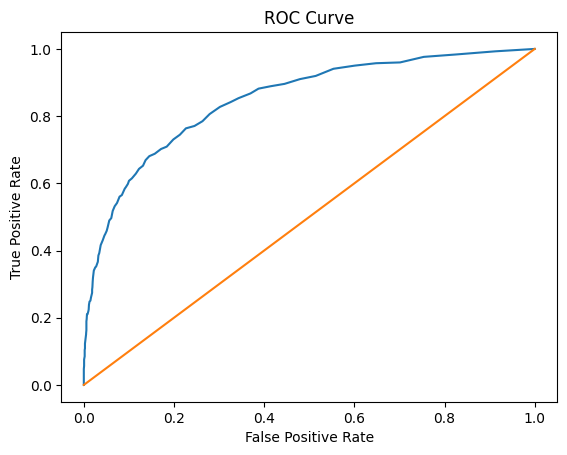

In [30]:

fpr, tpr, thresholds = roc_curve(objetivo_test, model_predic)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

La curva ROC muestra la relación entre la tasa de verdaderos positivos  y la tasa de falsos positivos  para distintos umbrales de decisión del modelo. En la gráfica se observa que la curva se mantiene claramente por encima de la línea diagonal, que representa un modelo que realiza predicciones al azar. Esto indica que el modelo tiene una buena capacidad para discriminar entre los clientes que abandonarán el banco y los que permanecerán. Además, el valor de AUC-ROC confirma que el modelo presenta un desempeño adecuado incluso en presencia de clases desbalanceadas, lo que permite identificar de manera más efectiva a los clientes con mayor probabilidad de churn.

El f1_score nos demuestra que el modelo detecta bien a los clientes que se van , en esta situacion ya que las clases estaban muy desbalanceadas use un umbral de .35 , para mejorar esa deteccion. Con ese umbral se logro un F1 de 0.607 lo que significa que el modelo logra un buen equilibrio entre recall  y precision , ayudando al objetivo del banco ya que es mejor detectar mas clientes que se van aunque haya algunos falosos positivos.